## Set up

In [1]:
import os
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.stats import sem

datapath = os.path.expanduser('~/projects/phd/occlusion_speed')

In [4]:
codes = ['5Hz_0occlusion', '5Hz_1occlusion', '5Hz_2occlusion', '5Hz_3occlusion', '20Hz_0occlusion', '20Hz_1occlusion', '20Hz_2occlusion', '20Hz_3occlusion']
means_anim={}
means_cat={}
means_obj={}
means_img={}

list_subjectnr =[]

for c in codes:
    y_anim=[]
    y_cat=[]
    y_obj=[]
    y_img=[]
    for j in range(1,50): 
        subjectnr='%02d'%j
        infn = f'{datapath}/derivatives/results/sub-{subjectnr}_results.csv'

        if os.path.exists(infn):
            list_subjectnr.append(subjectnr)

            D = pd.read_csv(infn)
            D.columns = D.columns.str.strip()
            time = D['time']
            Y_anim = D[f'animacy_decoding_{c}'].values
            y_anim.append(Y_anim)
            Y_cat = D[f'category_decoding_{c}'].values
            y_cat.append(Y_cat)
            Y_obj = D[f'object_decoding_{c}'].values
            y_obj.append(Y_obj)
            Y_img = D[f'image_decoding_{c}'].values
            y_img.append(Y_img)
         
    means_anim[c] = np.mean(np.array(y_anim).T,axis=1)
    means_cat[c] = np.mean(np.array(y_cat).T, axis=1)
    means_obj[c] = np.mean(np.array(y_obj).T,axis=1)
    means_img[c] = np.mean(np.array(y_img).T,axis=1)

list_subjectnr = np.unique(list_subjectnr)

In [5]:
conditions_5hz = [c for c in codes if c.startswith('5Hz')]
conditions_20hz = [c for c in codes if c.startswith('20Hz')]

timepoints = len(time)
slopes_5hz_anim = pd.DataFrame(index=list_subjectnr)
slopes_5hz_cat = slopes_5hz_anim.copy()
slopes_5hz_obj = slopes_5hz_anim.copy()
slopes_5hz_img = slopes_5hz_anim.copy()

slopes_20hz_anim = pd.DataFrame(index=list_subjectnr)
slopes_20hz_cat = slopes_20hz_anim.copy()
slopes_20hz_obj = slopes_20hz_anim.copy()
slopes_20hz_img = slopes_20hz_anim.copy()


for j in list_subjectnr:
    infn = f'{datapath}/derivatives/results/sub-{j}_results.csv'
    if not os.path.exists(infn):
        continue
    
    D = pd.read_csv(infn)
    D.columns = D.columns.str.strip()
    
    for t_idx in range(timepoints):

        Y_anim_5hz = [D[f'animacy_decoding_{c}'].values[t_idx] for c in conditions_5hz]
        slope = linregress([0, 1, 2, 3], Y_anim_5hz).slope
        slopes_5hz_anim.loc[j, t_idx] = slope
        Y_cat_5hz = [D[f'category_decoding_{c}'].values[t_idx] for c in conditions_5hz]
        slopes_5hz_cat.loc[j, t_idx] = linregress([0, 1, 2, 3], Y_cat_5hz).slope
        Y_obj_5hz = [D[f'object_decoding_{c}'].values[t_idx] for c in conditions_5hz]
        slopes_5hz_obj.loc[j, t_idx] = linregress([0, 1, 2, 3], Y_obj_5hz).slope
        Y_img_5hz = [D[f'image_decoding_{c}'].values[t_idx] for c in conditions_5hz]
        slopes_5hz_img.loc[j, t_idx] = linregress([0, 1, 2, 3], Y_img_5hz).slope


        Y_anim_20hz = [D[f'animacy_decoding_{c}'].values[t_idx] for c in conditions_20hz]
        slopes_20hz_anim.loc[j, t_idx] = linregress([0, 1, 2, 3], Y_anim_20hz).slope
        Y_cat_20hz = [D[f'category_decoding_{c}'].values[t_idx] for c in conditions_20hz]
        slopes_20hz_cat.loc[j, t_idx] = linregress([0, 1, 2, 3], Y_cat_20hz).slope
        Y_obj_20hz = [D[f'object_decoding_{c}'].values[t_idx] for c in conditions_20hz]
        slopes_20hz_obj.loc[j, t_idx] = linregress([0, 1, 2, 3], Y_obj_20hz).slope
        Y_img_20hz = [D[f'image_decoding_{c}'].values[t_idx] for c in conditions_20hz]
        slopes_20hz_img.loc[j, t_idx] = linregress([0, 1, 2, 3], Y_img_20hz).slope


C:\Users\90957667\AppData\Local\Temp\ipykernel_22812\2627928023.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  slopes_5hz_anim.loc[j, t_idx] = slope
C:\Users\90957667\AppData\Local\Temp\ipykernel_22812\2627928023.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  slopes_5hz_cat.loc[j, t_idx] = linregress([0, 1, 2, 3], Y_cat_5hz).slope
C:\Users\90957667\AppData\Local\Temp\ipykernel_22812\2627928023.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, 

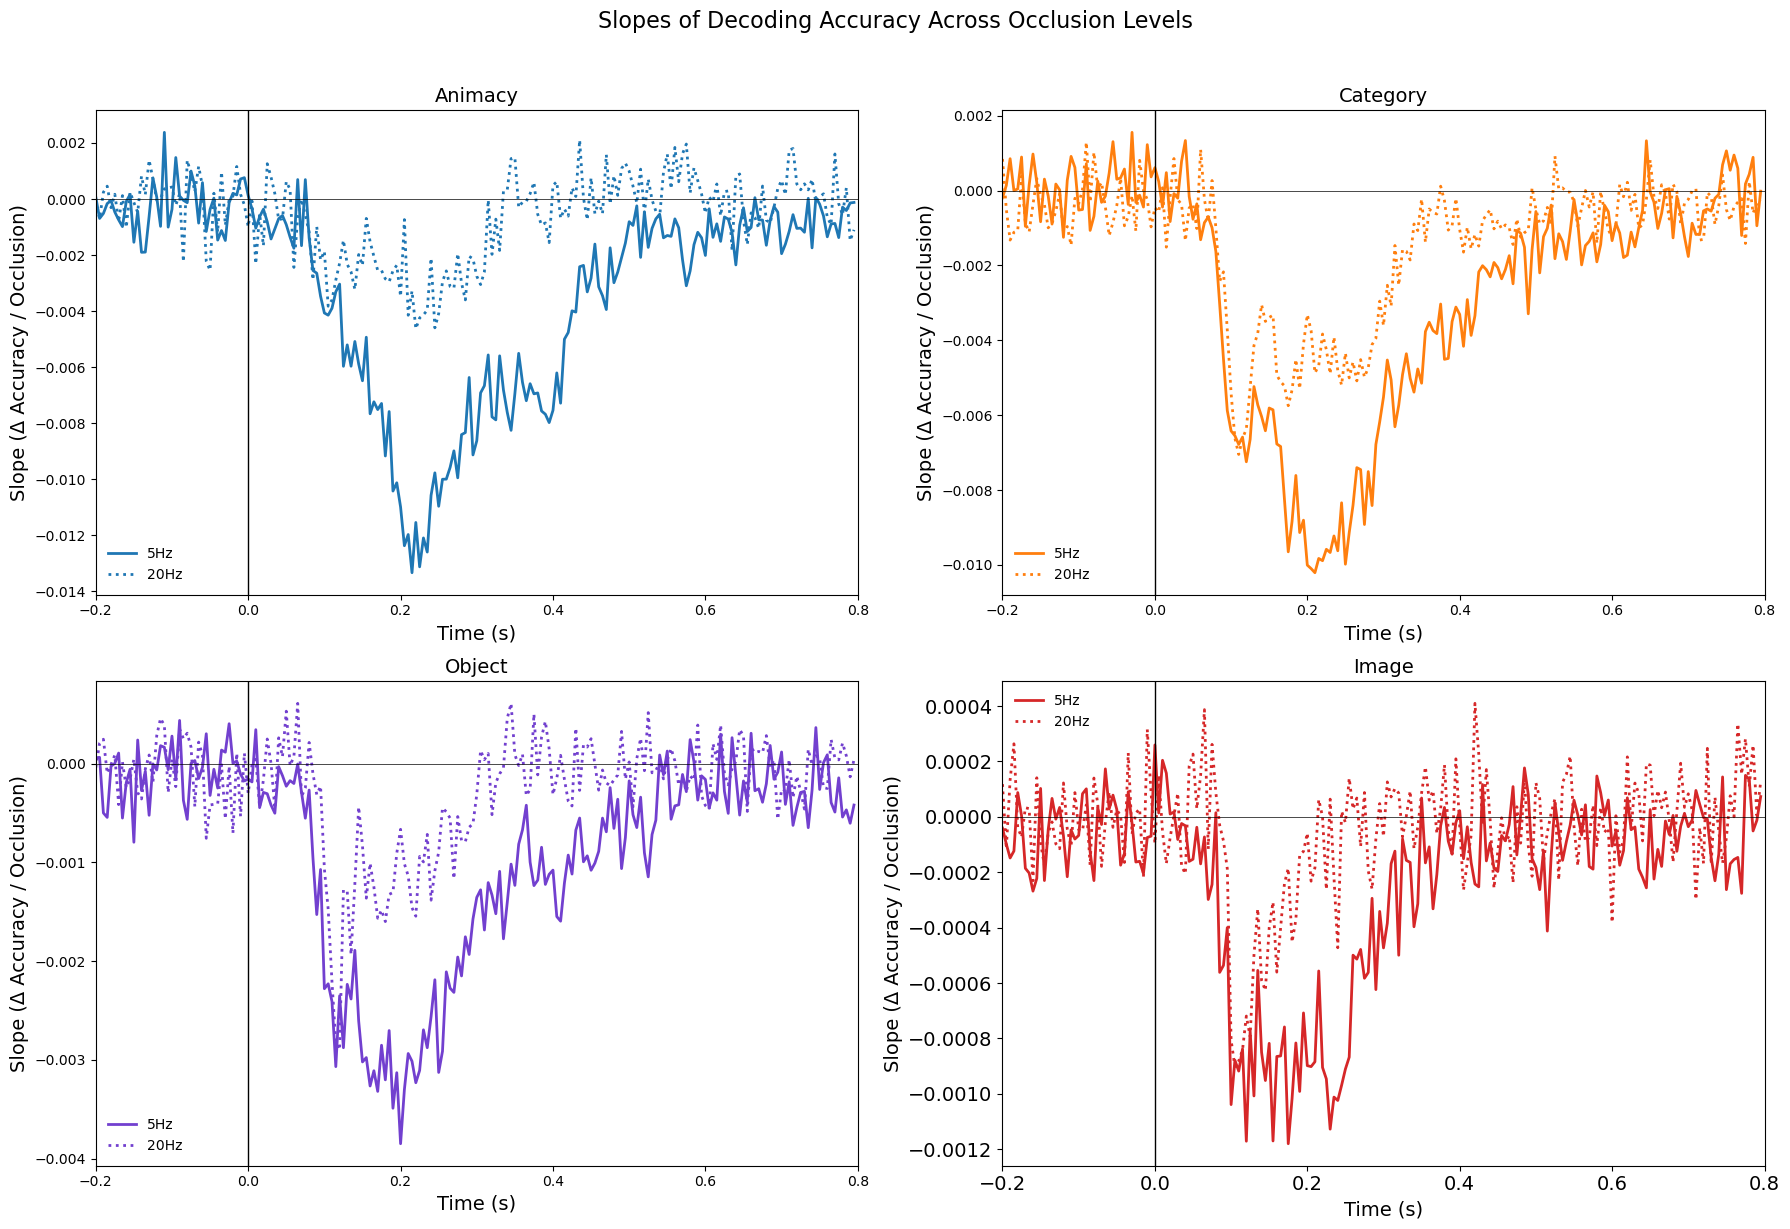

In [6]:

# Prepare time axis (adjust if your timepoints are in ms)
time_axis =  D['time'].values #CHANGE THIS TO FIT THE TIMEPOINTS PROPERLY

# Define decoding types and colors
decoding_types = {
    'anim': ('Animacy', '#1f77b4'),
    'cat': ('Category', '#ff7f0e'),
    'obj': ('Object', "#7240cf"),
    'img': ('Image', '#d62728')
}

# Create figures for 5Hz and 20Hz
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Slopes of Decoding Accuracy Across Occlusion Levels', fontsize=16, y=1.02)

# Plot function
def plot_slopes(ax, df_5hz, df_20hz, title, color):
    # Compute mean and SEM
    mean_5hz = df_5hz.mean(axis=0)
    sem_5hz = sem(df_5hz, axis=0)
    mean_20hz = df_20hz.mean(axis=0)
    sem_20hz = sem(df_20hz, axis=0)
    
    # Plot 5Hz
    ax.plot(time_axis, mean_5hz, color=color, label='5Hz', linewidth=2)
    #ax.fill_between(time_axis, mean_5hz - sem_5hz, mean_5hz + sem_5hz, color=color, alpha=0.2)
    
    # Plot 20Hz
    ax.plot(time_axis, mean_20hz, color=color, linestyle=':', label='20Hz', linewidth=2)
    #ax.fill_between(time_axis, mean_20hz - sem_20hz, mean_20hz + sem_20hz, color=color, alpha=0.1)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Time (s)', fontsize=14)
    ax.set_ylabel('Slope (Δ Accuracy / Occlusion)', fontsize=14)
    ax.set_xlim(-0.2, 0.8)
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
    ax.legend(frameon=False)

# Generate plots
for ax, (key, (title, color)) in zip(axes.flatten(), decoding_types.items()):
    plot_slopes(
        ax, 
        eval(f'slopes_5hz_{key}'),  # e.g., slopes_5hz_anim
        eval(f'slopes_20hz_{key}'), # e.g., slopes_20hz_anim
        title, 
        color
    )

plt.tight_layout()
plt.show()

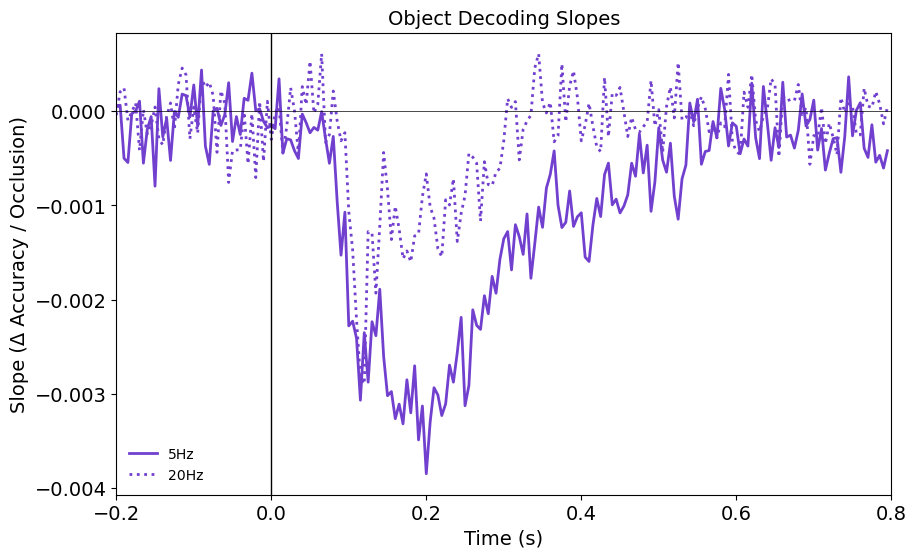

In [7]:
# If you only need one plot (for object decoding):
fig, ax = plt.subplots(figsize=(10, 6))
plot_slopes(
    ax, 
    slopes_5hz_obj,
    slopes_20hz_obj,
    title='Object Decoding Slopes', 
    color='#7240cf'
)
plt.show()

fig.savefig(f'{datapath}/derivatives/results/figures/category_slopes-animacy_paper.svg')

## Bayes Factors

In [24]:
from tqdm import tqdm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVR, LinearSVC


from rpy2.robjects import r
from rpy2.robjects.packages import importr
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter


bf_package=importr('BayesFactor')
pandas2ri.activate()

In [8]:
slopes_5hz_anim_bf= slopes_5hz_anim.T
slopes_20hz_anim_bf= slopes_20hz_anim.T
slopes_5hz_obj_bf= slopes_5hz_obj.T
slopes_20hz_obj_bf= slopes_20hz_obj.T


In [ ]:
# calculating the difference between 5 and 20 hz slopes
df_diff_animacy = pd.DataFrame()
df_diff_object = pd.DataFrame()

for col in slopes_5hz_anim_bf.columns:
    df_diff_animacy[col] = []
    df_diff_object[col] = []


for col5, col20 in zip(slopes_5hz_anim_bf.columns, slopes_20hz_anim_bf.columns):
    # row[0] is the index, row[1] is the Series of values
    values_5hz = slopes_5hz_anim_bf[col5].values
    values_20hz = slopes_20hz_anim_bf[col20].values
    values = values_5hz - values_20hz
    df_diff_animacy[col5] = values

for col5, col20 in zip(slopes_5hz_obj_bf.columns, slopes_20hz_obj_bf.columns):
    values_5hz = slopes_5hz_obj_bf[col5].values
    values_20hz = slopes_20hz_obj_bf[col20].values
    values = values_5hz - values_20hz
    df_diff_object[col5] = values

In [12]:
df_diff_object

,01,02,03,04,05,06,07,08,09,10,...,20,21,22,23,24,25,26,27,28,29
0,0.001043,-0.002797,-0.001789,-0.000187,-0.001457,0.001841,-0.003213,-0.000877,-0.001269,0.000745,...,-0.003643,0.000756,-0.000880,0.000343,0.000698,0.001380,-0.001236,0.001544,-0.002349,0.002009
1,0.002419,0.001779,0.000039,-0.001441,0.000501,-0.000206,-0.000017,-0.005761,-0.002182,-0.002872,...,0.000620,-0.000827,0.000336,0.002718,-0.000593,-0.002159,0.002550,0.000525,-0.000973,-0.000643
2,-0.000311,-0.002237,-0.000721,-0.000102,0.000028,0.004186,-0.000293,-0.002734,-0.001352,-0.000521,...,-0.000366,-0.002467,-0.000129,-0.004174,-0.003320,-0.004269,-0.003099,0.000327,-0.001375,-0.000756
3,-0.000583,-0.000540,-0.005682,0.004074,-0.002242,0.002583,0.000244,-0.003417,0.002658,0.002840,...,-0.003284,-0.002278,-0.001997,-0.001303,0.002781,-0.001868,-0.003447,-0.003375,-0.001914,-0.001475
4,0.000417,-0.002287,-0.001980,0.001830,-0.003315,0.000945,0.000388,-0.000199,-0.002532,0.002900,...,-0.000621,0.000075,-0.001241,0.000309,0.005203,0.000948,-0.003013,-0.000136,-0.004396,0.000727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.001892,0.000136,0.002302,-0.001910,0.000783,-0.002290,0.002702,-0.002188,0.000059,0.005273,...,-0.002509,0.001855,0.001683,0.006519,0.002943,-0.002516,-0.000570,-0.003591,-0.002399,0.000156
196,-0.002166,-0.000754,0.000306,-0.004905,0.001395,-0.004594,0.001783,-0.000687,0.003112,0.001896,...,-0.002836,0.000699,0.000496,0.001283,-0.000341,-0.000776,0.001926,-0.005199,0.001909,-0.001034
197,0.000604,0.001279,-0.002194,-0.004189,-0.000153,-0.000563,0.002520,0.000508,0.001322,-0.001255,...,-0.004128,0.001966,0.000721,-0.002812,-0.001361,-0.001163,-0.002501,-0.000533,0.001271,0.001199
198,0.000408,-0.000573,-0.001032,-0.004889,0.001686,-0.001808,0.005593,-0.000760,-0.000896,-0.005905,...,-0.003352,0.004385,0.001255,-0.002813,0.003001,-0.002374,0.001152,-0.000393,0.000033,0.000331


## Animate

In [55]:
null_interval = ro.FloatVector([-0.5, 0.5]) #we are taking the complement of this to get the full Cauchy


times = slopes_5hz_anim_bf['01'].index #the rows are the timepoints
n_timepoints = len(times)


mu = 0
r_data5 = pandas2ri.py2rpy(slopes_5hz_anim_bf)
r_data20 = pandas2ri.py2rpy(slopes_20hz_anim_bf)
bfs = []
for t in range(1, n_timepoints + 1): #R is 1-indexed
    time_point_data5 = r_data5.rx(t, True)  # All columns (participants) for a specific timepoint
    time_point_data5 = ro.r['as.numeric'](time_point_data5)  # Convert to numeric vector
    time_point_data20 = r_data20.rx(t,True)
    time_point_data20 = ro.r['as.numeric'](time_point_data20)
    time_point_data5 = time_point_data5[~np.isnan(time_point_data5)]
    time_point_data20 = time_point_data20[~np.isnan(time_point_data20)]
    x = time_point_data5 #for 5 Hz
    y = time_point_data20 #for 20 Hz
    if len(time_point_data5) > 1 and len(time_point_data20):  # Ensure there's enough data to perform the test
        print('there is enough data')
        results = bf_package.ttestBF(x=x, y =y , mu=mu,paired = True, rscale='medium', nullInterval=null_interval)
        bf_value = np.asarray(ro.r['as.vector'](results))[1] #TODO: double-check whether 1 is the complement
        bfs.append(bf_value)
    else:
        bfs.append(np.nan)




there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enou

In [57]:
bf_diff = pd.DataFrame(bfs, index = times)

In [58]:
bf_diff

,0
0,0.001807
1,0.001764
2,0.004617
3,0.004419
4,0.002031
...,...
195,0.010278
196,0.002064
197,0.005589
198,0.016476


Time axis shape: (200,)
Slopes 5Hz shape: (28, 200)
Slopes 20Hz shape: (28, 200)
BF diff shape: (200, 1)


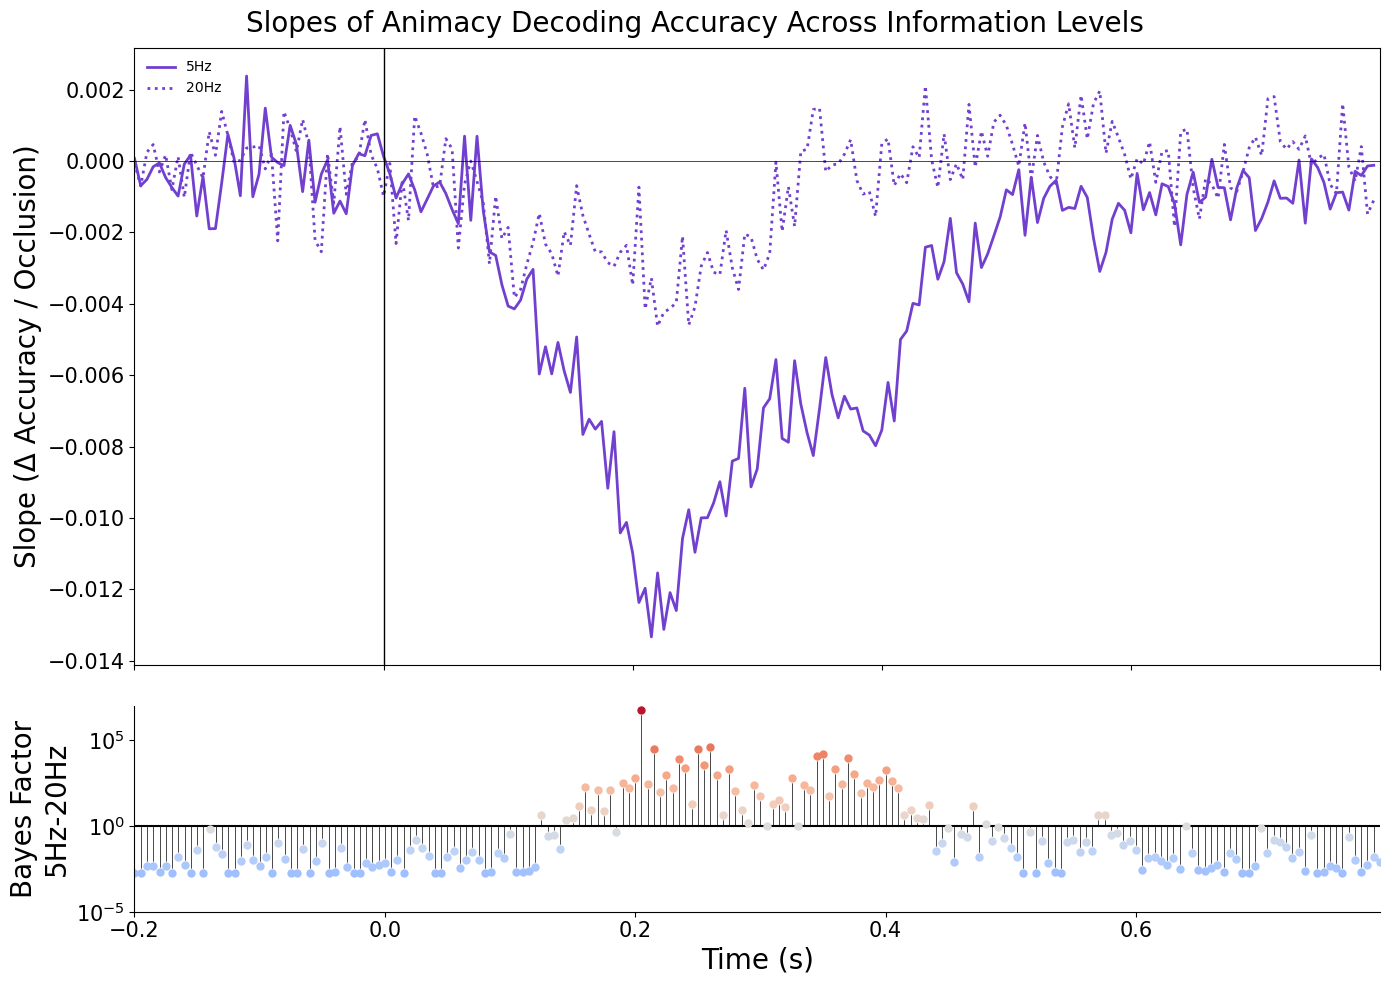

In [90]:

# Prepare time axis
time_axis = D['time'].values

# Define decoding types and colors
decoding_types = {
    'anim': ('Animacy', '#1f77b4'),
    'cat': ('Category', '#ff7f0e'),
    'obj': ('Object', "#7240cf"),
    'img': ('Image', '#d62728')
}

# Create figure with two subplots of different heights
fig, (ax_slope, ax_bf) = plt.subplots(2, 1, figsize=(14, 10), 
                                      gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Slopes of Animacy Decoding Accuracy Across Information Levels', fontsize=20, y=0.98)

# Function to plot slopes
def plot_slopes(ax, df_5hz, df_20hz, title, color):
    # Convert DataFrames to numpy arrays if needed
    if hasattr(df_5hz, 'values'):
        df_5hz = df_5hz.values.copy()
    if hasattr(df_20hz, 'values'):
        df_20hz = df_20hz.values.copy()
    
    # Find the minimum length across all arrays
    min_length = min(len(time_axis), 
                    df_5hz.shape[1] if df_5hz.ndim > 1 else len(df_5hz), 
                    df_20hz.shape[1] if df_20hz.ndim > 1 else len(df_20hz))
    
    # Adjust all arrays to the same length
    time_adj = time_axis[:min_length]
    
    if df_5hz.ndim > 1:
        df_5hz_adj = df_5hz[:, :min_length]
    else:
        df_5hz_adj = df_5hz[:min_length]
        
    if df_20hz.ndim > 1:
        df_20hz_adj = df_20hz[:, :min_length]
    else:
        df_20hz_adj = df_20hz[:min_length]
    
    # Compute mean and SEM
    mean_5hz = np.mean(df_5hz_adj, axis=0) if df_5hz_adj.ndim > 1 else df_5hz_adj
    #sem_5hz = sem(df_5hz_adj, axis=0) if df_5hz_adj.ndim > 1 else np.zeros_like(df_5hz_adj)
    
    mean_20hz = np.mean(df_20hz_adj, axis=0) if df_20hz_adj.ndim > 1 else df_20hz_adj
    #sem_20hz = sem(df_20hz_adj, axis=0) if df_20hz_adj.ndim > 1 else np.zeros_like(df_20hz_adj)
    
    # Plot slopes
    ax.plot(time_adj, mean_5hz, color=color, label='5Hz', linewidth=2)
    #if df_5hz_adj.ndim > 1:  # Only plot SEM if we have multiple samples
    #    ax.fill_between(time_adj, mean_5hz - sem_5hz, mean_5hz + sem_5hz, color=color, alpha=0.2)
    
    ax.plot(time_adj, mean_20hz, color=color, linestyle=':', label='20Hz', linewidth=2)
    #if df_20hz_adj.ndim > 1:  # Only plot SEM if we have multiple samples
    #    ax.fill_between(time_adj, mean_20hz - sem_20hz, mean_20hz + sem_20hz, color=color, alpha=0.1)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    #ax.set_title(title, fontsize=20)
    ax.set_ylabel('Slope (Δ Accuracy / Occlusion)', fontsize=20)
    ax.set_xlim(-0.2, 0.8)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.legend(loc='upper left', frameon=False)
    
    # Remove x-axis labels from the top plot
    ax.set_xticklabels([])
    
    return ax

# Function to plot Bayes Factors
def plot_bayes_factors(ax, bf_diff, time_axis):
    # Ensure bf_diff is a 1D array
    bf_diff = np.array(bf_diff).flatten()
    
    # Find the minimum length
    min_length = min(len(time_axis), len(bf_diff))
    time_adj = time_axis[:min_length]
    bf_diff_adj = bf_diff[:min_length]
    
    # Plot all Bayes Factors using stem plot style
    exponential_minmax = 7
    val_col_map = np.logspace(-exponential_minmax, exponential_minmax, num=500)
    bf_cols = plt.cm.coolwarm(np.linspace(0, 1, 500))
    
    # Create stem plot for all Bayes Factors
    markerline, stemlines, baseline = ax.stem(time_adj, bf_diff_adj, bottom=1, 
                                             linefmt='k', markerfmt='o', basefmt=None)
    markerline.set_markerfacecolor('w')
    markerline.set_markeredgecolor('w')
    baseline.set_color('k')
    stemlines.set_linewidth(0.5)
    
    # Color the points based on Bayes Factor values
    cols_idx = [np.argmin(np.abs(val_col_map - abs(val))) for val in bf_diff_adj]  
    for i in range(len(cols_idx)):
        ax.plot(time_adj[i], bf_diff_adj[i], color=bf_cols[cols_idx[i]], marker='.', markersize=10)
    
    # Format the Bayes Factor axis
    ax.set_yscale('log')
    ax.set_ylim([10 ** -5, 10 ** exponential_minmax])
    ax.set_yticks([1.e-5, 1, 1.e+5])
    ax.set_xlim([time_adj[0], time_adj[-1]])
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_ylabel('Bayes Factor\n5Hz-20Hz', fontsize=20)
    ax.set_xlabel('Time (s)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)
    
    # Add horizontal lines for Bayes Factor thresholds
    #ax.axhline(y=3, color='gray', linestyle='--', alpha=0.7, linewidth=1, label='BF=3')
    #ax.axhline(y=1/3, color='gray', linestyle='--', alpha=0.7, linewidth=1, label='BF=1/3')
    #ax.legend(loc='upper right', frameon=False)
    
    return ax

# Check your data dimensions first
print(f"Time axis shape: {time_axis.shape}")
print(f"Slopes 5Hz shape: {slopes_5hz_anim.shape if hasattr(slopes_5hz_anim, 'shape') else len(slopes_5hz_anim)}")
print(f"Slopes 20Hz shape: {slopes_20hz_anim.shape if hasattr(slopes_20hz_anim, 'shape') else len(slopes_20hz_anim)}")
print(f"BF diff shape: {bf_diff.shape if hasattr(bf_diff, 'shape') else len(bf_diff)}")

# Plot the slopes on the top subplot
plot_slopes(
    ax_slope, 
    slopes_5hz_anim,  
    slopes_20hz_anim, 
    title='Animacy Decoding Slopes', 
    color='#7240cf'
)

# Plot the Bayes Factors on the bottom subplot
plot_bayes_factors(
    ax_bf,
    bf_diff,          
    time_axis
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)  # Reduce space between subplots
plt.show()

# Save the figure
fig.savefig(f'{datapath}/derivatives/results/figures/category_slopes-bfs-animacy.svg', bbox_inches='tight')

### Objects

In [84]:
null_interval = ro.FloatVector([-0.5, 0.5]) #we are taking the complement of this to get the full Cauchy


times = slopes_5hz_obj_bf['01'].index #the rows are the timepoints
n_timepoints = len(times)


mu = 0
r_data5 = pandas2ri.py2rpy(slopes_5hz_obj_bf)
r_data20 = pandas2ri.py2rpy(slopes_20hz_obj_bf)
bfs = []
for t in range(1, n_timepoints + 1): #R is 1-indexed
    time_point_data5 = r_data5.rx(t, True)  # All columns (participants) for a specific timepoint
    time_point_data5 = ro.r['as.numeric'](time_point_data5)  # Convert to numeric vector
    time_point_data20 = r_data20.rx(t,True)
    time_point_data20 = ro.r['as.numeric'](time_point_data20)
    time_point_data5 = time_point_data5[~np.isnan(time_point_data5)]
    time_point_data20 = time_point_data20[~np.isnan(time_point_data20)]
    x = time_point_data5 #for 5 Hz
    y = time_point_data20 #for 20 Hz
    if len(time_point_data5) > 1 and len(time_point_data20):  # Ensure there's enough data to perform the test
        #print('there is enough data')
        results = bf_package.ttestBF(x=x, y =y , mu=mu,paired = True, rscale='medium', nullInterval=null_interval)
        bf_value = np.asarray(ro.r['as.vector'](results))[1] #TODO: double-check whether 1 is the complement
        bfs.append(bf_value)
    else:
        bfs.append(np.nan)

bf_diff_obj = pd.DataFrame(bfs, index = times)


there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enough data
there is enou

Time axis shape: (200,)
Slopes 5Hz shape: (28, 200)
Slopes 20Hz shape: (28, 200)
BF diff shape: (200, 1)


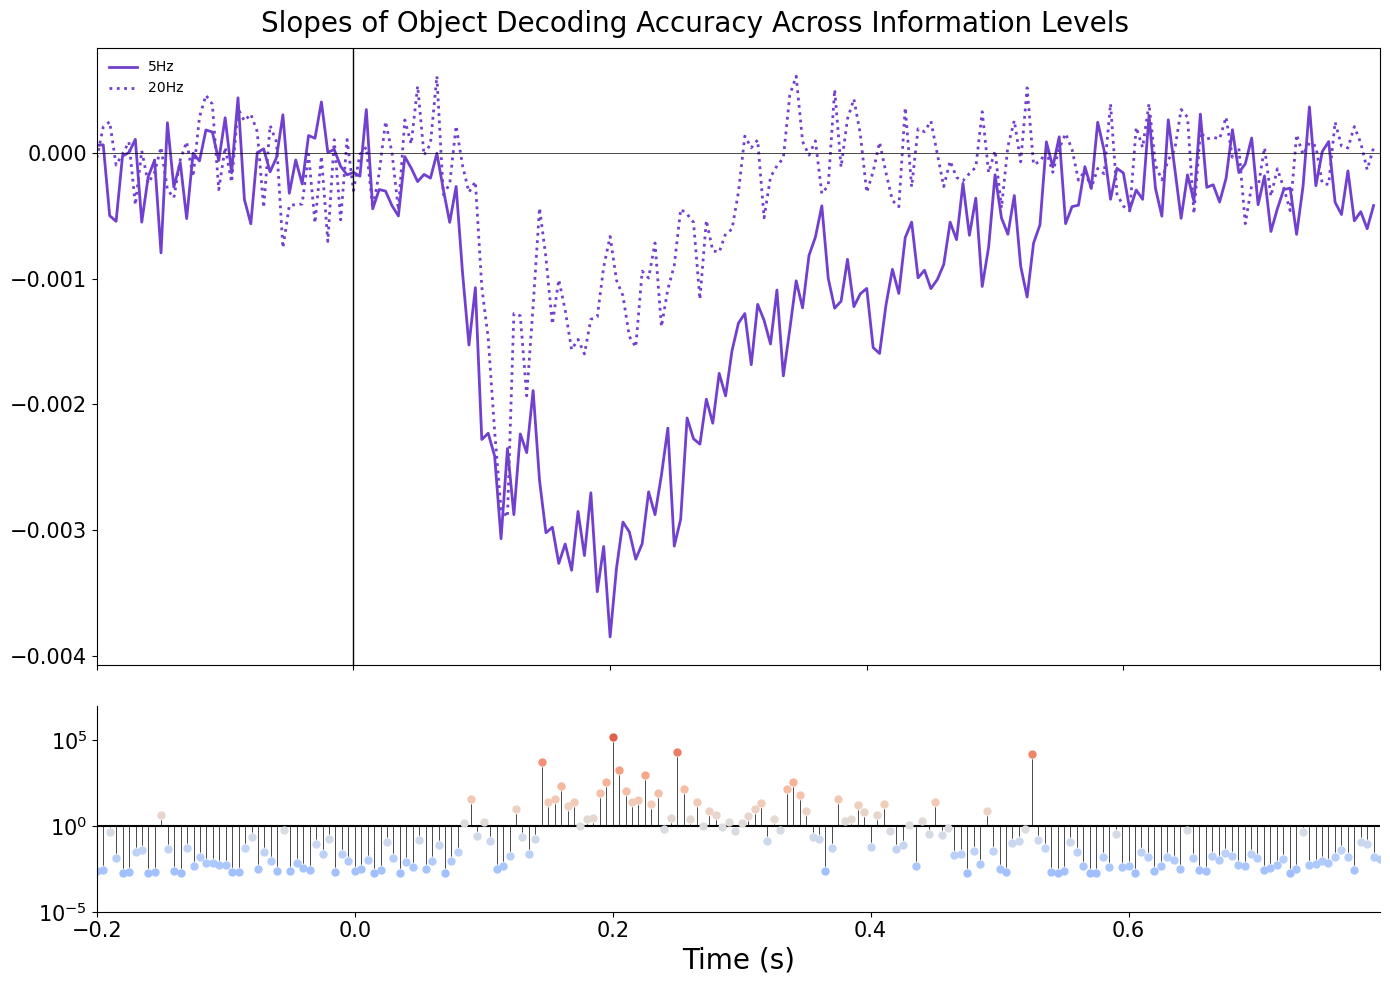

In [91]:

# Prepare time axis
time_axis = D['time'].values

# Define decoding types and colors
decoding_types = {
    'anim': ('Animacy', '#1f77b4'),
    'cat': ('Category', '#ff7f0e'),
    'obj': ('Object', "#7240cf"),
    'img': ('Image', '#d62728')
}

# Create figure with two subplots of different heights
fig, (ax_slope, ax_bf) = plt.subplots(2, 1, figsize=(14, 10), 
                                      gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Slopes of Object Decoding Accuracy Across Information Levels', fontsize=20, y=0.98)

# Function to plot slopes
def plot_slopes(ax, df_5hz, df_20hz, title, color):
    # Convert DataFrames to numpy arrays if needed
    if hasattr(df_5hz, 'values'):
        df_5hz = df_5hz.values.copy()
    if hasattr(df_20hz, 'values'):
        df_20hz = df_20hz.values.copy()
    
    # Find the minimum length across all arrays
    min_length = min(len(time_axis), 
                    df_5hz.shape[1] if df_5hz.ndim > 1 else len(df_5hz), 
                    df_20hz.shape[1] if df_20hz.ndim > 1 else len(df_20hz))
    
    # Adjust all arrays to the same length
    time_adj = time_axis[:min_length]
    
    if df_5hz.ndim > 1:
        df_5hz_adj = df_5hz[:, :min_length]
    else:
        df_5hz_adj = df_5hz[:min_length]
        
    if df_20hz.ndim > 1:
        df_20hz_adj = df_20hz[:, :min_length]
    else:
        df_20hz_adj = df_20hz[:min_length]
    
    # Compute mean and SEM
    mean_5hz = np.mean(df_5hz_adj, axis=0) if df_5hz_adj.ndim > 1 else df_5hz_adj
    #sem_5hz = sem(df_5hz_adj, axis=0) if df_5hz_adj.ndim > 1 else np.zeros_like(df_5hz_adj)
    
    mean_20hz = np.mean(df_20hz_adj, axis=0) if df_20hz_adj.ndim > 1 else df_20hz_adj
    #sem_20hz = sem(df_20hz_adj, axis=0) if df_20hz_adj.ndim > 1 else np.zeros_like(df_20hz_adj)
    
    # Plot slopes
    ax.plot(time_adj, mean_5hz, color=color, label='5Hz', linewidth=2)
    #if df_5hz_adj.ndim > 1:  # Only plot SEM if we have multiple samples
    #    ax.fill_between(time_adj, mean_5hz - sem_5hz, mean_5hz + sem_5hz, color=color, alpha=0.2)
    
    ax.plot(time_adj, mean_20hz, color=color, linestyle=':', label='20Hz', linewidth=2)
    #if df_20hz_adj.ndim > 1:  # Only plot SEM if we have multiple samples
    #    ax.fill_between(time_adj, mean_20hz - sem_20hz, mean_20hz + sem_20hz, color=color, alpha=0.1)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    #ax.set_title(title, fontsize=20)
    #ax.set_ylabel('Slope (Δ Accuracy / Occlusion)', fontsize=20)
    ax.set_xlim(-0.2, 0.8)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.legend(loc='upper left', frameon=False)
    
    # Remove x-axis labels from the top plot
    ax.set_xticklabels([])
    
    return ax

# Function to plot Bayes Factors
def plot_bayes_factors(ax, bf_diff, time_axis):
    # Ensure bf_diff is a 1D array
    bf_diff = np.array(bf_diff).flatten()
    
    # Find the minimum length
    min_length = min(len(time_axis), len(bf_diff))
    time_adj = time_axis[:min_length]
    bf_diff_adj = bf_diff[:min_length]
    
    # Plot all Bayes Factors using stem plot style
    exponential_minmax = 7
    val_col_map = np.logspace(-exponential_minmax, exponential_minmax, num=500)
    bf_cols = plt.cm.coolwarm(np.linspace(0, 1, 500))
    
    # Create stem plot for all Bayes Factors
    markerline, stemlines, baseline = ax.stem(time_adj, bf_diff_adj, bottom=1, 
                                             linefmt='k', markerfmt='o', basefmt=None)
    markerline.set_markerfacecolor('w')
    markerline.set_markeredgecolor('w')
    baseline.set_color('k')
    stemlines.set_linewidth(0.5)
    
    # Color the points based on Bayes Factor values
    cols_idx = [np.argmin(np.abs(val_col_map - abs(val))) for val in bf_diff_adj]  
    for i in range(len(cols_idx)):
        ax.plot(time_adj[i], bf_diff_adj[i], color=bf_cols[cols_idx[i]], marker='.', markersize=10)
    
    # Format the Bayes Factor axis
    ax.set_yscale('log')
    ax.set_ylim([10 ** -5, 10 ** exponential_minmax])
    ax.set_yticks([1.e-5, 1, 1.e+5])
    ax.set_xlim([time_adj[0], time_adj[-1]])
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    #ax.set_ylabel('Bayes Factor\n5Hz-20Hz', fontsize=20)
    ax.set_xlabel('Time (s)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)
    
    # Add horizontal lines for Bayes Factor thresholds
    #ax.axhline(y=3, color='gray', linestyle='--', alpha=0.7, linewidth=1, label='BF=3')
    #ax.axhline(y=1/3, color='gray', linestyle='--', alpha=0.7, linewidth=1, label='BF=1/3')
    #ax.legend(loc='upper right', frameon=False)
    
    return ax

# Check your data dimensions first
print(f"Time axis shape: {time_axis.shape}")
print(f"Slopes 5Hz shape: {slopes_5hz_obj.shape if hasattr(slopes_5hz_obj, 'shape') else len(slopes_5hz_obj)}")
print(f"Slopes 20Hz shape: {slopes_20hz_obj.shape if hasattr(slopes_20hz_obj, 'shape') else len(slopes_20hz_obj)}")
print(f"BF diff shape: {bf_diff.shape if hasattr(bf_diff, 'shape') else len(bf_diff)}")

# Plot the slopes on the top subplot
plot_slopes(
    ax_slope, 
    slopes_5hz_obj,  
    slopes_20hz_obj, 
    title='Object Decoding Slopes', 
    color='#7240cf'
)

# Plot the Bayes Factors on the bottom subplot
plot_bayes_factors(
    ax_bf,
    bf_diff_obj,          
    time_axis
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)  # Reduce space between subplots
plt.show()

# Save the figure
fig.savefig(f'{datapath}/derivatives/results/figures/category_slopes-bfs-object.svg', bbox_inches='tight')